In [2]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
from kagglehub import KaggleDatasetAdapter

print(pd.__version__)

3.0.3


In [3]:
# Set the path to the file you'd like to load
file_path = "ai_workforce_displacement_global_2020_2026.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "alitaqishah/ai-workforce-displacement-20202026",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

/var/folders/xx/qwxqz_3j4ts16b4kdkn37_x40000gn/T/ipykernel_7474/2915852684.py:5: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


In [4]:
df.shape

(20800, 23)

In [5]:
df.columns

Index(['record_id', 'country', 'iso3_code', 'region', 'income_group', 'year',
       'quarter', 'quarter_label', 'industry_sector',
       'sector_automation_risk_score', 'gdp_per_capita_usd',
       'ai_adoption_index', 'pct_sector_workforce_displaced',
       'pct_sector_workforce_new_roles_created', 'net_workforce_change_pct',
       'ai_cited_layoff_announcements', 'ai_skill_wage_premium_pct',
       'pct_workforce_female', 'pct_displaced_roles_female',
       'reskilling_programs_count', 'govt_ai_policy_score_1_to_10',
       'ai_tool_adoption_pct', 'data_source_notes'],
      dtype='str')

# KK1 - AI och arbetsmarknadpåverkan 2020-2026

## Kontext

Datasetet är skapat av Syed Ali Taqi och publicerat på Kaggle.
Det innerhåller 20 800 rader där varje rad representerar ett land + sektor + kvartal, totalt 80 länder, 10 industri sektorer tex Tech & software, Ekonomi och banker, Utbildning, transportation och forskning

Kolumnerna mäter bland annat automationsrisk per sektor, BNP per capita, förflyttad arbetskraft, roller skapasdse av AI och regeringarnas AI politikscore.

## Begränsningar
Datan representerar inte faktiska mätningar, den är syntetisk och forskningskalibrerad.



In [6]:
df["industry_sector"].unique()


<StringArray>
[     'Technology & Software',          'Finance & Banking',
 'Healthcare & Life Sciences',   'Manufacturing & Industry',
        'Retail & E-Commerce',       'Education & Research',
 'Transportation & Logistics',     'Media & Communications',
  'Administrative & Clerical',         'Energy & Utilities']
Length: 10, dtype: str

In [7]:
df["country"].unique()

<StringArray>
[ 'United States',          'China',        'Germany', 'United Kingdom',
          'Japan',         'France',          'India',         'Canada',
    'South Korea',      'Australia',         'Brazil',          'Italy',
          'Spain',         'Mexico',      'Indonesia',    'Netherlands',
   'Saudi Arabia',         'Turkey',    'Switzerland',         'Sweden',
         'Norway',        'Denmark',        'Finland',        'Belgium',
        'Austria',         'Poland',      'Argentina',       'Colombia',
          'Chile',           'Peru',   'South Africa',        'Nigeria',
          'Egypt',          'Kenya',       'Ethiopia',          'Ghana',
        'Morocco',       'Tanzania',       'Pakistan',     'Bangladesh',
        'Vietnam',       'Thailand',       'Malaysia',    'Philippines',
      'Singapore',    'New Zealand',       'Portugal', 'Czech Republic',
        'Romania',        'Hungary',         'Greece',        'Ukraine',
         'Israel',            'UAE', 

In [8]:
df

,record_id,country,iso3_code,region,income_group,year,quarter,quarter_label,industry_sector,sector_automation_risk_score,...,pct_sector_workforce_new_roles_created,net_workforce_change_pct,ai_cited_layoff_announcements,ai_skill_wage_premium_pct,pct_workforce_female,pct_displaced_roles_female,reskilling_programs_count,govt_ai_policy_score_1_to_10,ai_tool_adoption_pct,data_source_notes
0,1,United States,USA,North America,High Income,2020,1,2020-Q1,Technology & Software,0.382,...,0.0348,-0.0058,32,0.311,0.28,0.275,52,6.4,0.280,Research-calibrated synthetic data. Grounded i...
1,2,United States,USA,North America,High Income,2020,1,2020-Q1,Finance & Banking,0.608,...,0.0423,-0.0094,51,0.304,0.48,0.511,39,6.5,0.559,Research-calibrated synthetic data. Grounded i...
2,3,United States,USA,North America,High Income,2020,1,2020-Q1,Healthcare & Life Sciences,0.198,...,0.0168,-0.0008,4,0.278,0.72,0.707,37,6.8,0.202,Research-calibrated synthetic data. Grounded i...
3,4,United States,USA,North America,High Income,2020,1,2020-Q1,Manufacturing & Industry,0.720,...,0.0642,-0.0282,47,0.268,0.29,0.310,50,6.8,0.655,Research-calibrated synthetic data. Grounded i...
4,5,United States,USA,North America,High Income,2020,1,2020-Q1,Retail & E-Commerce,0.676,...,0.0374,-0.0293,31,0.313,0.54,0.547,37,6.2,0.542,Research-calibrated synthetic data. Grounded i...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20795,20796,Zambia,ZMB,Africa,Lower Middle Income,2026,2,2026-Q2,Education & Research,0.308,...,0.0056,-0.0162,29,0.450,0.58,0.651,16,3.5,0.184,Research-calibrated synthetic data. Grounded i...
20796,20797,Zambia,ZMB,Africa,Lower Middle Income,2026,2,2026-Q2,Transportation & Logistics,0.675,...,0.0205,-0.0329,126,0.476,0.22,0.235,15,4.2,0.457,Research-calibrated synthetic data. Grounded i...
20797,20798,Zambia,ZMB,Africa,Lower Middle Income,2026,2,2026-Q2,Media & Communications,0.516,...,0.0154,-0.0351,131,0.446,0.46,0.482,17,4.3,0.419,Research-calibrated synthetic data. Grounded i...
20798,20799,Zambia,ZMB,Africa,Lower Middle Income,2026,2,2026-Q2,Administrative & Clerical,0.801,...,0.0260,-0.0654,476,0.499,0.79,0.950,14,4.2,0.459,Research-calibrated synthetic data. Grounded i...


In [32]:
df[df["country"] == "Sweden"].shape


(260, 23)

## Inläsning och mekanisk inspektion
Här kollar jag på kolumnerna som finns det finns 23 kolumner totalt, men inga värden saknas så jag behöver inte tvätta datan.
Det finns olika datatyper, strängar(7), int64(6), float64(10) totalt 20 800 rader med data.

In [9]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 20800 entries, 0 to 20799
Data columns (total 23 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   record_id                               20800 non-null  int64  
 1   country                                 20800 non-null  str    
 2   iso3_code                               20800 non-null  str    
 3   region                                  20800 non-null  str    
 4   income_group                            20800 non-null  str    
 5   year                                    20800 non-null  int64  
 6   quarter                                 20800 non-null  int64  
 7   quarter_label                           20800 non-null  str    
 8   industry_sector                         20800 non-null  str    
 9   sector_automation_risk_score            20800 non-null  float64
 10  gdp_per_capita_usd                      20800 non-null  int64  
 11  

,record_id,year,quarter,sector_automation_risk_score,gdp_per_capita_usd,ai_adoption_index,pct_sector_workforce_displaced,pct_sector_workforce_new_roles_created,net_workforce_change_pct,ai_cited_layoff_announcements,ai_skill_wage_premium_pct,pct_workforce_female,pct_displaced_roles_female,reskilling_programs_count,govt_ai_policy_score_1_to_10,ai_tool_adoption_pct
count,20800.000000,20800.000000,20800.000000,20800.000000,20800.000000,20800.000000,20800.000000,20800.000000,20800.000000,20800.000000,20800.000000,20800.000000,20800.000000,20800.000000,20800.000000,20800.000000
mean,10400.500000,2022.769231,2.423077,0.537881,21003.330769,0.692148,0.056155,0.035631,-0.020524,88.346538,0.361570,0.462000,0.497154,34.497981,5.370067,0.372712
std,6004.587135,1.887406,1.115411,0.190345,22048.862955,0.161194,0.044811,0.036586,0.015327,85.198076,0.094132,0.188833,0.222239,22.688847,1.566616,0.166875
min,1.000000,2020.000000,1.000000,0.151000,879.000000,0.169000,0.001800,0.000300,-0.140300,0.000000,0.063000,0.220000,0.213000,2.000000,1.100000,0.037000
25%,5200.750000,2021.000000,1.000000,0.379000,3456.500000,0.591000,0.023300,0.009800,-0.028200,24.000000,0.293000,0.280000,0.290000,13.000000,4.000000,0.231000
50%,10400.500000,2023.000000,2.000000,0.580000,10635.000000,0.720000,0.043400,0.021900,-0.016400,63.000000,0.366000,0.470000,0.493000,30.000000,5.400000,0.365000
75%,15600.250000,2024.000000,3.000000,0.698000,40528.500000,0.821000,0.074900,0.049400,-0.009100,126.000000,0.435000,0.580000,0.610000,53.000000,6.800000,0.498000
max,20800.000000,2026.000000,4.000000,0.855000,99074.000000,0.963000,0.300000,0.279100,-0.000300,603.000000,0.610000,0.790000,0.950000,92.000000,8.800000,0.881000


## Outlier
Som jag senare kommer försöka visa så finns det Outlier i denna statistiken som gör att det inte alls blir korrekt när jag försöker sätta en mean, jag har ett annat repo som jag övade på och fick upp ögonen för detta, ska försöka hitta och föra in det här för att visa att det had ehamnat på att hela annat värde, tex gdp per capita. från 50% ärt det 10635 och 75% så hoppar det till 40528.

Frågan : Vilka länder Automatiserar mer än andra?

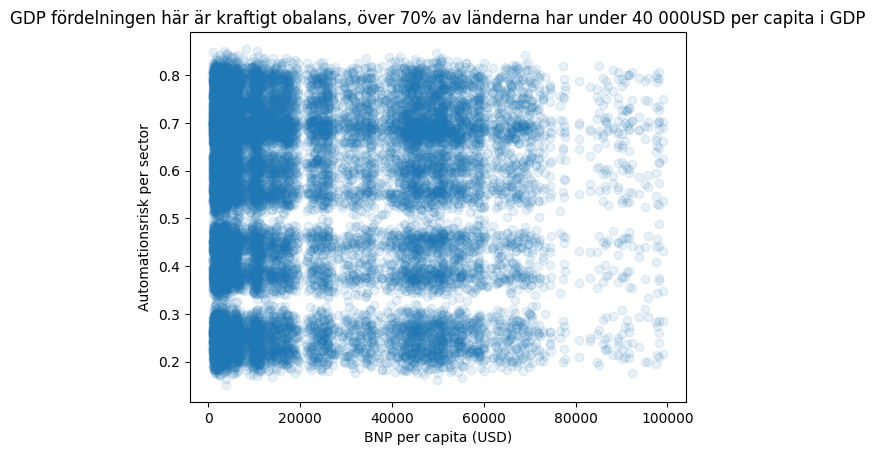

In [10]:
plt.scatter(df["gdp_per_capita_usd"], df["sector_automation_risk_score"], alpha=0.1)
plt.title("GDP fördelningen här är kraftigt obalans, över 70% av länderna har under 40 000USD per capita i GDP")
plt.xlabel("BNP per capita (USD)")
plt.ylabel("Automationsrisk per sector")
plt.show()

In [31]:
df["income_group"].value_counts()


income_group
High Income            8060
Lower Middle Income    6240
Upper Middle Income    5720
Low Income              780
Name: count, dtype: int64

## Ville få ut median istället
Gick inte så bra att göra det på att scatter diagram eftersom det endast visar relation mellan två råvärden, men det som visas är att desto mindre BNP desto högre automationsrisk per sector, det för mig till nästa fråga som jag har längre ner.
Hur klarar sig länderna som har sådan låg bnp och ändå en sådan hög automationsrisk?
Tvungen att göra df["income_group"].value_counts() för att kolla varför det är så mycket mer vid låg BNP än störra.

Gjorde en df[df["country"] == "Sweden"].shape för att se hur många rader Sverige har tillexempel det var 260st.

Diagrammet är vilseledande eftersom Low, lower middle och upper middle hamnar rätt nära varandra och då ser det ut som endast "fattiga" länder har mer automationsrisk.
Så "desto mindre BNP desto högre automationsrisk håller inte, det är ett felaktigt påstående.

Det korrekta påståendet är att länder med högre BNP har mer automationsrisk och ersättning vilket visas längre ner



## Fråga
I mitt första diagram ovan fick jag diagrammet som visade BNP och automationsrisk per sektor, då är min nästa fråga vad är in distri sectorn och vilka olika automations risker har dem ?

In [11]:
df.groupby("industry_sector")["sector_automation_risk_score"].mean().sort_values()

industry_sector
Healthcare & Life Sciences    0.219736
Education & Research          0.270071
Technology & Software         0.379583
Energy & Utilities            0.449988
Media & Communications        0.550444
Finance & Banking             0.610245
Transportation & Logistics    0.680379
Retail & E-Commerce           0.689231
Manufacturing & Industry      0.739386
Administrative & Clerical     0.789742
Name: sector_automation_risk_score, dtype: float64

## Vilken sektor är i högst utsatt av automation?
Gör en group by för att föra få en överblick innan jag bestämmer mig för vilket diagram jag vill ha, eftersom jag vill göra mean och få medelvärdet så bestämmer jag mig för stapeldiagram.
Mean tror jag är bättre här då fördelning i varje sektor är mer symmetrisk än i GDP jämförelsen då vissa extremt rika länder sticker iväg från resten.

Tech & software 0.37, vilket är nice för oss som pluggar just det här.

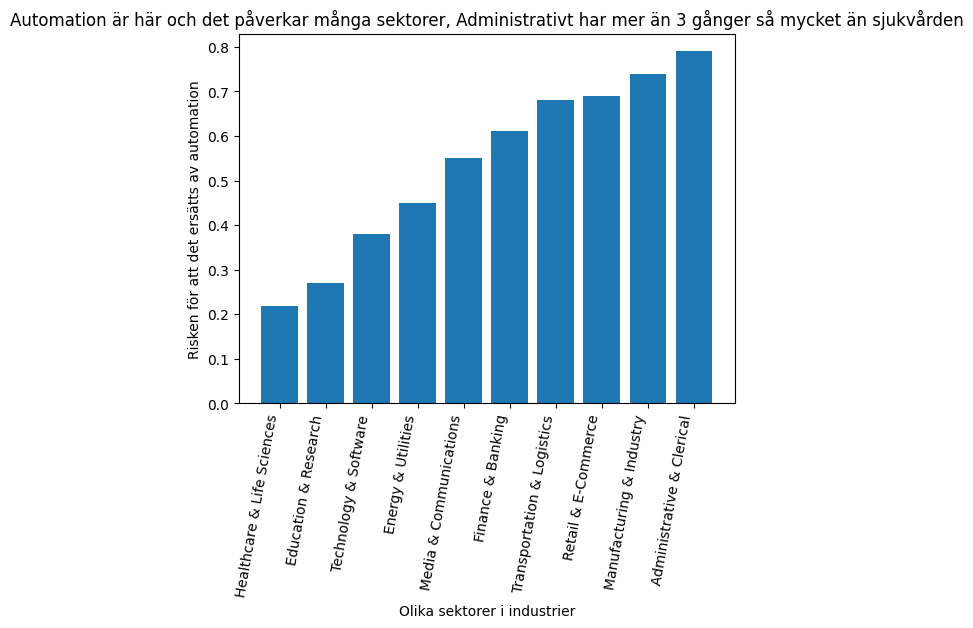

In [12]:
sector_risk = df.groupby("industry_sector")["sector_automation_risk_score"].mean().sort_values()
plt.bar(sector_risk.index, sector_risk.values)
plt.xticks(rotation=80, ha="right")
plt.title("Automation är här och det påverkar många sektorer, Administrativt har mer än 3 gånger så mycket än sjukvården")
plt.xlabel("Olika sektorer i industrier")
plt.ylabel("Risken för att det ersätts av automation")
plt.show()

## Utforskning genom visualisering
Jag bara dök rakt ner och gjorde två grafer direkt för att det fångade min uppmärksamhet något otroligt, hoppas det går att se i flödet.
Detta ger en tydlig bild på hur olika sektorer påverkas och vilket gapp det är imellan.
Från 0.2 upp till 0.8 som är 4x skillnad från den lägsta till högsta.
Tydligt att tech och software är 3e lägst med 0.38 och ändå är de det jag hör mest hype och att den industrin är död.

## Datatvätt, tyvärr så finns det ingen data att tvätta så jag får hoppa det.


## Vilka länder annonserar flest AI relaterade varsel?

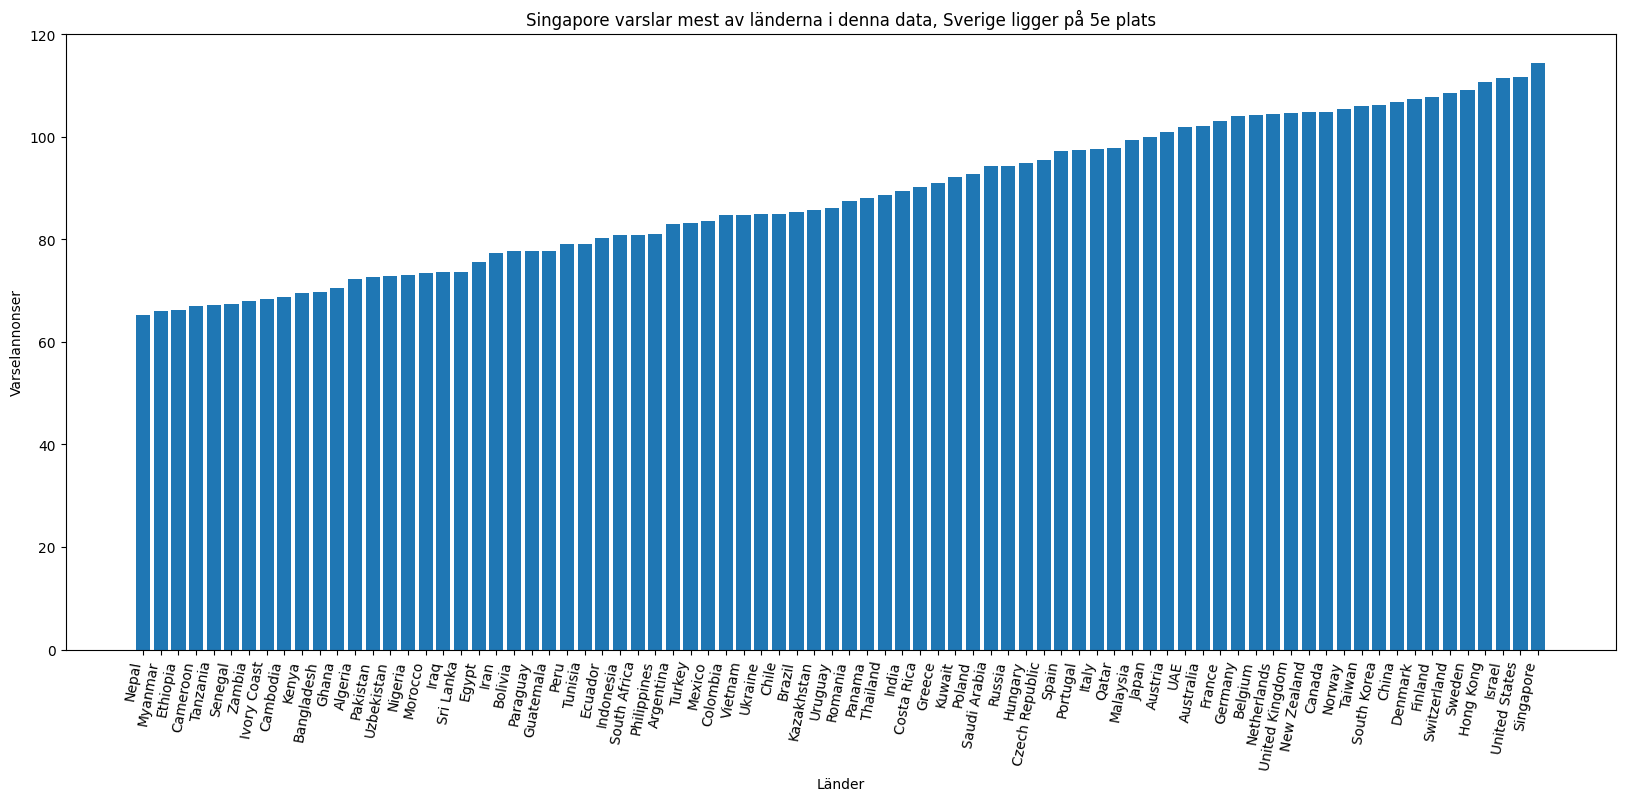

In [13]:
ai_varsel = df.groupby("country")["ai_cited_layoff_announcements"].mean().sort_values()
plt.figure(figsize=(20, 8))
plt.bar(ai_varsel.index, ai_varsel.values)
plt.xticks(rotation=80, ha="right")
plt.title("Singapore varslar mest av länderna i denna data, Sverige ligger på 5e plats")
plt.xlabel("Länder")
plt.ylabel("Varselannonser")
plt.show()

## Skillnad från land till land
Nepal har nästan dubbelt så lite än Singapore.
Det är varslingsannonser, ej personer så det är per annons. 
Detta ger en tydlig bild på hur länder som är rika och långt fram i utvecklingen har fler varselannonser. Det gör att jag får en annan fråga, hur gör vi med jobb för oss i våra länder?

Dock så i många av länderna i topp förutom asiatiska länder så är det låg med befolkning. Hur gör Kina med en befolkning och sådan stor automatisering?
I mitt scatter diagram så visade det högre automations i länder med lägre bnp, dock så visas det här att många av de rika länderna har högre varselannonser än de fattiga.

## AI adoption över tid (INDEX)
Hur fort har det gått med AI över dem senaste åren 2020 - 2026?

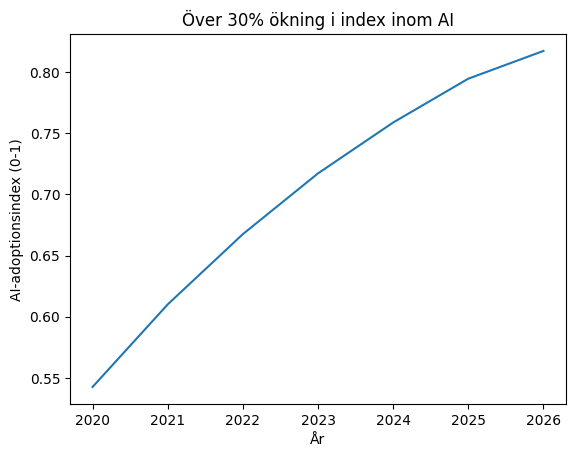

In [14]:
adoption = df.groupby("year")["ai_adoption_index"].mean()
plt.plot(adoption.index, adoption.values)
plt.title("Över 30% ökning i index inom AI")
plt.ylabel("AI-adoptionsindex (0-1)")
plt.xlabel("År")
plt.show()

## Notera att det är Index, ej procent
Det börjar inte på 0 i indexering, eftersom 2020 låg det redan runt 0.55 så bestämde jag att inte lägga att y axeln skulle börja på 0.
Det är en kraftig ökning på 30% under 6 år.

## Hur påverkas ländes med olika income av automation?

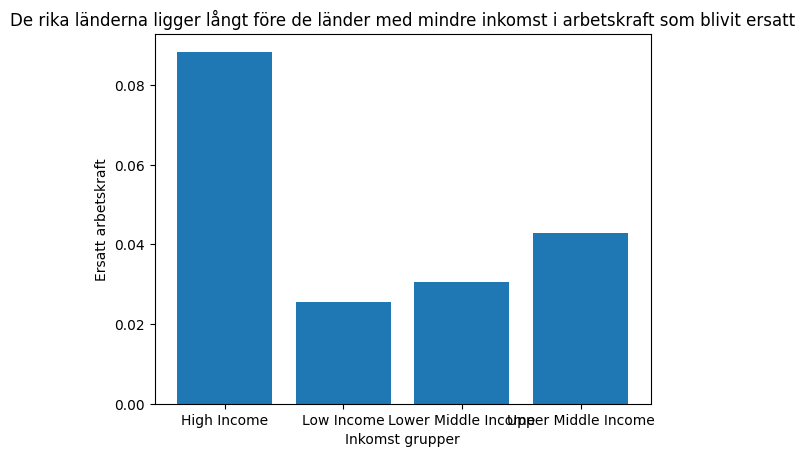

In [27]:
workforce = df.groupby("income_group")["pct_sector_workforce_displaced"].mean()
plt.bar(workforce.index, workforce.values)
plt.title("De rika länderna ligger långt före de länder med mindre inkomst i arbetskraft som blivit ersatt")
plt.xlabel("Inkomst grupper")
plt.ylabel("Ersatt arbetskraft")
plt.show()

## Det är tydligt i detta diagram hur high income blir ersatt mycket mer av automation
Jag tror att det är rika länder som kan vara mer i framkant med utvecklinng och addoptera automation av nya sorter fortare än vad fattiga länder kan.
Det visas i grafen ovan att det har stigit mycket under de senaste 6 åren.
Därav så visar denna grafen att det är hög inkomstagande länder som adpoterar automation och AI snabbare än vad fattiga länder gör.

## Vad är skillnaden mellan de 10 fattigaste och de 10 rikaste länderna samt 10 länderna som ligger i mitten?

income_group
High Income            8060
Lower Middle Income    6240
Upper Middle Income    5720
Low Income              780
Name: count, dtype: int64